Training samples: 614
Training samples: 154
Training Insulin (fit on train, transform both


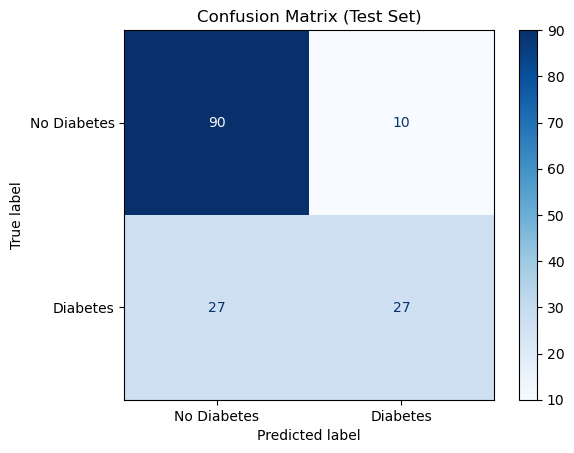


==== Test set Performance =====

Classification Report:

              precision    recall  f1-score   support

           0       0.77      0.90      0.83       100
           1       0.73      0.50      0.59        54

    accuracy                           0.76       154
   macro avg       0.75      0.70      0.71       154
weighted avg       0.76      0.76      0.75       154

(614, 1) (614,)
(154, 1) (154,)


C:\Users\pgcp-bda\AppData\Local\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


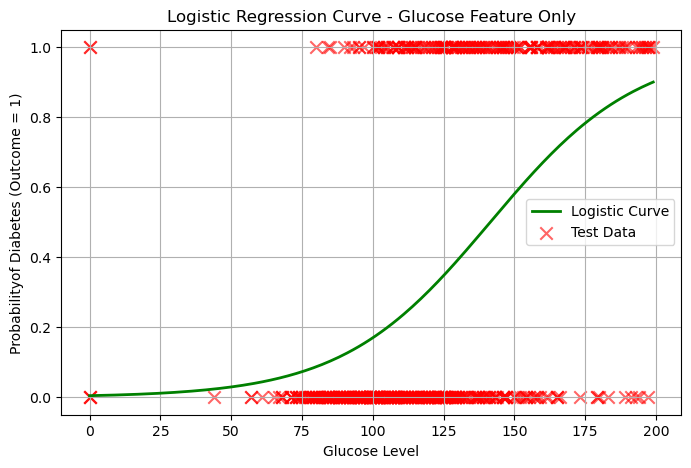

In [22]:
#logistic regression - diabetes
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix,classification_report,ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler

#=============================================
#1.Load and prepare data
#=============================================

df = pd.read_csv("diabetes.csv")
x=df.drop("Outcome",axis = 1)
y=df["Outcome"]

#============================================
#2.Train-test split
#============================================
x_train,x_test,y_train,y_test = train_test_split(
    x,y,test_size=0.2,random_state=101,stratify=y
)
print(f"Training samples: {len(x_train)}")
print(f"Training samples: {len(x_test)}")

print(f"Training Insulin (fit on train, transform both")
#3.Standardize Insulin (fit on train,transform)
scaler = StandardScaler()
x_train["Insulin"] = scaler.fit_transform(x_train[["Insulin"]])
x_test["Insulin"] = scaler.transform(x_test[["Insulin"]]) #Use same scaler

#4.Train full model (all feaqtures)
model = LogisticRegression(max_iter = 500)
model.fit(x_train,y_train)

#5.Evaluation on TEST set
y_pred = model.predict(x_test)

cm = confusion_matrix(y_test,y_pred)
ConfusionMatrixDisplay(cm,display_labels=["No Diabetes","Diabetes"]).plot(cmap="Blues")
plt.title("Confusion Matrix (Test Set)")
plt.show()

print("\n==== Test set Performance =====")
print("\nClassification Report:\n")
print(classification_report(y_test,y_pred))

#6. Logistic Regression Curve ( Glucose only - for visualization)

x_train_glucose = x_train[["Glucose"]].copy()
x_test_glucose = x_test[["Glucose"]].copy()
print(x_train_glucose.shape,y_train.shape)
print(x_test_glucose.shape,y_test.shape)


#Train a seperate single-feature model for vizualization

model_glucose = LogisticRegression(max_iter=500)
model_glucose.fit(x_train_glucose,y_train)
#Create smooth curve
glucose_min = df["Glucose"].min()
glucose_max = df["Glucose"].max()
glucose_values = np.linspace(glucose_min,glucose_max,200).reshape(-1,1)

y_curve = model_glucose.predict_proba(glucose_values)[:,1]

#Plot sigmoid curve with train/test split visualization
plt.figure(figsize=(8,5))
plt.plot(glucose_values,y_curve,color = "green",linewidth = 2,label="Logistic Curve")
plt.scatter(x_train_glucose,y_train,color="red",alpha=0.6,marker="x",s=80,label="Test Data")
plt.xlabel("Glucose Level")
plt.ylabel("Probabilityof Diabetes (Outcome = 1)")
plt.title("Logistic Regression Curve - Glucose Feature Only")
plt.legend()
plt.grid()
plt.show()


In [ ]:
# Confusion Matrix - Exercise

# Out of 1000 emails,800 non-spams were classified correctly, 20 were incorrectly classified as spam, 40 were incorrectly classified as non-spam, and the 
# remaining spams were identified correctly

# Write null hypothesis and create a confusion matrix

#A bank's fraud detection system analyzed 1,000 credit card transactions. Out of these, 400 transactions were flagged as fraudluent by the system. In reality
# 350 transactions were actually fraudluent. Among the flagged transactions, 300 were truly fraudluent.

# Based on this information, calculate the True Positives(TP), True Negetives(TN),False Positives(Fp) and False Negatives(FN), and construct the confusion
# matrix


Training samples: 712
Training samples: 179
Training Survive (fit on train, transform both pclass and age
     pclass  gender       age
517       3    male  0.003802
71        3  female -1.060521
550       1    male -0.982828
250       3    male  0.003802
36        3    male  0.003802
..      ...     ...       ...
716       1  female  0.648721
183       2    male -2.225914
168       1    male  0.003802
179       3    male  0.493336
571       1  female  1.814114

[179 rows x 3 columns]

Label Encoded 'gender' :
      gender
517       1
71        0
550       1
250       1
36        1

label Encoded 'gender': 
      gender
353       1
137       1
494       1
430       1
589       1


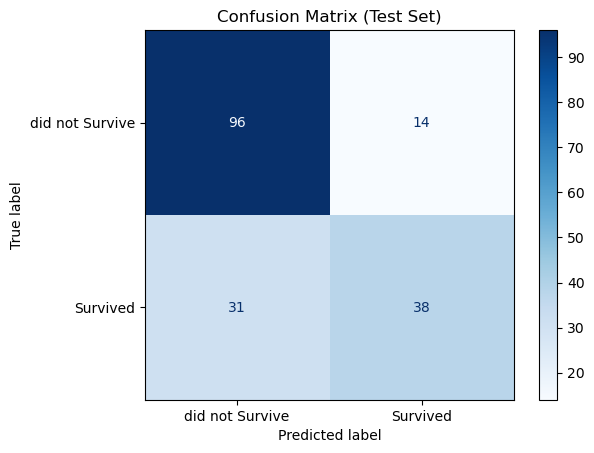


==== Test set Performance =====

Classification Report:

              precision    recall  f1-score   support

           0       0.76      0.87      0.81       110
           1       0.73      0.55      0.63        69

    accuracy                           0.75       179
   macro avg       0.74      0.71      0.72       179
weighted avg       0.75      0.75      0.74       179



In [25]:
#Perform Logistic regression on titanic dataset

#Use x = df[["pclass","gender","age"]]
#Y=df["survived"]

#Encoded gender
#Scale age

#display confusion matrix and classification report

#logistic regression - titanic
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix,classification_report,ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler,LabelEncoder, OneHotEncoder


#=============================================
#1.Load and prepare data
#=============================================

df = pd.read_csv("titanic.csv")
x = df[["pclass","gender","age"]]
x = x.fillna(df["age"].mean())
y=df["survived"]

#============================================
#2.Train-test split
#============================================
x_train,x_test,y_train,y_test = train_test_split(
    x,y,test_size=0.2,random_state=101,stratify=y
)
print(f"Training samples: {len(x_train)}")
print(f"Training samples: {len(x_test)}")

print(f"Training Survive (fit on train, transform both pclass and age") 

#3.Standardize Insulin (fit on train,transform)
scaler = StandardScaler()
x_train["age"] = scaler.fit_transform(x_train[["age"]])
x_test["age"] = scaler.transform(x_test[["age"]]) #Use same scaler
print(x_test)
#Create new dataframe with OHE columns

# label_encoder = LabelEncoder()
# x_test['gender']= label_encoder.fit_transform(x_test['gender'])
# x_train['gender']= label_encoder.fit_transform(x_train['gender'])
# print("\nLabel Encoded 'gender' :\n", x_test[['gender']].head())
# print("\nlabel Encoded 'gender': \n", x_train[['gender']].tail())

#One-hot encode
model = LogisticRegression(max_iter = 500)
model.fit(x_train,y_train)

# #5.Evaluation on TEST set
y_pred = model.predict(x_test)

cm = confusion_matrix(y_test,y_pred)
ConfusionMatrixDisplay(cm,display_labels=["did not Survive","Survived"]).plot(cmap="Blues")
plt.title("Confusion Matrix (Test Set)")
plt.show()

print("\n==== Test set Performance =====")
print("\nClassification Report:\n")
print(classification_report(y_test,y_pred))

